# 🔧 Notebook 02 — Data Preprocessing & Feature Engineering
## Du dataset brut au feature store prêt-à-clusterer

---

## Section 0 — Contexte & Objectif du Pipeline

Le notebook EDA (`01_eda.ipynb`) a conclu avec **6 hypothèses de segmentation** et une liste de **9 features** à construire. Ce notebook transforme ces spécifications en un feature store exploitable.

### Les 9 features cibles

| # | Feature | Source | Construction |
|---|---------|--------|-------------|
| 1 | `Log_Recency` | `last_purchase_date` | `log1p((max_date − last_date).days)` |
| 2 | `Log_Monetary` | `total_spent` | `log1p(total_spent)` après clip P99 |
| 3 | `Frequency_flag` | `total_orders` | `int(total_orders ≥ 2)` |
| 4 | `avg_freight_ratio` | `df_master` (item level) | `mean(freight_value / price)` par client |
| 5 | `avg_delivery_delay` | `df_master` (order level) | `mean(actual − estimated)` par client |
| 6 | `avg_review_score` | `get_customer_aggregation()` | déjà disponible |
| 7 | `payment_type_cc_flag` | `olist_order_payments` | `int(mode(payment_type) == 'credit_card')` |
| 8 | `avg_installments` | `olist_order_payments` | `mean(payment_installments)` par client |
| 9 | `region_freight_score` | `customer_state` | encodage ordinal région × charge de fret |

### Pipeline de transformation

```
PostgreSQL
  ├─ get_merged_dataframe()      → df_master  (grain: order × item × payment)
  ├─ get_customer_aggregation()  → df_agg     (grain: customer, 6 cols)
  └─ olist_order_payments        → pay_raw    (grain: order × payment)
        │
        ▼
  [Section 2] Feature Construction  (logistics + payments + geography)
        │
        ▼
  [Section 3] Feature Store Assembly (merge séquentiel, grain: customer)
        │
        ▼
  [Section 4] Outlier Treatment      (clip P99, bornes physiques)
        │
        ▼
  [Section 5] Imputation             (médiane/zéro, assert nulls == 0)
        │
        ▼
  [Section 6] Log-Transform & Encode (log1p Recency+Monetary)
        │
        ▼
  [Section 7] StandardScaler         (mean=0, std=1 par feature)
        │
        ▼
  [Section 8] Export + Diagnostics   (parquet + PCA 2D + heatmap corr)
```

> **⚠️ Contrainte clustering :** K-Means et CAH reposent sur des distances euclidiennes. Des features non normalisées créent des biais de scale — une feature en milliers domine une feature en 0–5. Le `StandardScaler` est **obligatoire** avant tout algorithme basé sur des distances.

## Section 1 — Setup & Chargement des Sources

**Pourquoi 3 sources distinctes ?**
- `get_customer_aggregation()` donne le RFM de base (6 colonnes) mais pas les features comportementales
- `get_merged_dataframe()` est au grain `order × item × payment` — il faut dédupliquer avant d'agréger au niveau client
- `olist_order_payments` est chargé séparément pour construire proprement les features paiement (éviter les Cartesian products du JOIN multi-table)

La règle : **toute agrégation au niveau client doit passer par une déduplication explicite** au grain approprié (item, order, ou payment).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import warnings
import sys
import os
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from IPython.display import display

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# ── Chemins projet ────────────────────────────────────────────────────────────
PROJECT_ROOT = Path(os.getcwd()).parent
sys.path.append(str(PROJECT_ROOT / 'src'))

PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR    = PROJECT_ROOT / 'models'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ── Connexion PostgreSQL ───────────────────────────────────────────────────────
from data_loader import get_db_engine, get_merged_dataframe, get_customer_aggregation

engine = get_db_engine()

# ── Chargement des 3 sources ───────────────────────────────────────────────────
print('Chargement df_master (order × item × payment)...')
df_master = get_merged_dataframe(engine)

print('Chargement df_agg (customer level, 6 cols)...')
df_agg = get_customer_aggregation(engine)

print('Chargement olist_order_payments (grain: order × payment)...')
pay_raw = pd.read_sql_table('olist_order_payments', engine)

# ── Mapping géographique (réutilisé depuis EDA) ───────────────────────────────
STATE_REGION = {
    'AC': 'Norte',  'AM': 'Norte',  'AP': 'Norte',  'PA': 'Norte',
    'RO': 'Norte',  'RR': 'Norte',  'TO': 'Norte',
    'AL': 'Nordeste', 'BA': 'Nordeste', 'CE': 'Nordeste', 'MA': 'Nordeste',
    'PB': 'Nordeste', 'PE': 'Nordeste', 'PI': 'Nordeste', 'RN': 'Nordeste', 'SE': 'Nordeste',
    'DF': 'Centro-Oeste', 'GO': 'Centro-Oeste', 'MS': 'Centro-Oeste', 'MT': 'Centro-Oeste',
    'ES': 'Sudeste', 'MG': 'Sudeste', 'RJ': 'Sudeste', 'SP': 'Sudeste',
    'PR': 'Sul', 'RS': 'Sul', 'SC': 'Sul'
}
# Encodage ordinal : Sul (fret faible) → Norte (fret élevé)
REGION_FREIGHT_ORDER = {'Sul': 1, 'Sudeste': 2, 'Centro-Oeste': 3, 'Nordeste': 4, 'Norte': 5}

print(f'\n✅ Sources chargées :')
print(f'   df_master : {df_master.shape[0]:>8,} lignes × {df_master.shape[1]} colonnes')
print(f'   df_agg    : {df_agg.shape[0]:>8,} clients')
print(f'   pay_raw   : {pay_raw.shape[0]:>8,} lignes')

2026-04-12 00:00:29,670 - INFO - Fetching and merging data from PostgreSQL...


Chargement df_master (order × item × payment)...


2026-04-12 00:00:30,776 - INFO - Successfully fetched 115723 rows.


2026-04-12 00:00:30,777 - INFO - Fetching customer-level aggregated data from PostgreSQL...


Chargement df_agg (customer level, 6 cols)...


2026-04-12 00:00:31,137 - INFO - Successfully fetched 93358 customer records.


Chargement olist_order_payments (grain: order × payment)...



✅ Sources chargées :
   df_master :  115,723 lignes × 35 colonnes
   df_agg    :   93,358 clients
   pay_raw   :  103,886 lignes


## Section 2 — Construction des Features Comportementales

### Déduplication : règle d'or

Le `df_master` résulte d'un JOIN multi-table : pour chaque commande, les lignes d'items (`order_item_id`) sont croisées avec les lignes de paiement (`payment_sequential`). Une commande avec 2 articles et 2 modes de paiement génère **4 lignes** dans df_master.

Règle d'agrégation :
- **Features item-level** (`freight_ratio`) → dédupliquer à `(order_id, order_item_id)` avant mean
- **Features order-level** (`delivery_delay_days`) → dédupliquer à `order_id` avant mean
- **Features paiement** (`installments`, `payment_type`) → travailler depuis `pay_raw` joint à `olist_orders`

In [2]:
# ── Pré-calcul des colonnes temporelles (reproduit depuis EDA) ─────────────────
for col in ['order_purchase_timestamp', 'order_approved_at',
            'order_delivered_carrier_date', 'order_delivered_customer_date',
            'order_estimated_delivery_date']:
    df_master[col] = pd.to_datetime(df_master[col], errors='coerce')

df_master['actual_lead_time_days']    = (df_master['order_delivered_customer_date'] -
                                          df_master['order_purchase_timestamp']).dt.total_seconds() / 86400
df_master['estimated_lead_time_days'] = (df_master['order_estimated_delivery_date'] -
                                          df_master['order_purchase_timestamp']).dt.total_seconds() / 86400
df_master['delivery_delay_days']      = (df_master['actual_lead_time_days'] -
                                          df_master['estimated_lead_time_days'])
df_master['freight_ratio']            = df_master['freight_value'] / df_master['price']
df_master['is_late']                  = (df_master['delivery_delay_days'] > 0).astype(int)

# ── 2-A : Features logistiques (grain: order × item → mean par client) ─────────
# Déduplique au grain order × item pour éviter les doublons dus au JOIN paiements
df_items = df_master.drop_duplicates(subset=['order_id', 'order_item_id']).copy()

customer_freight = df_items.groupby('customer_unique_id').agg(
    avg_freight_ratio = ('freight_ratio', 'mean'),
).reset_index()

# Déduplique au grain order pour les métriques de délai
df_orders = df_master.drop_duplicates(subset=['order_id']).copy()

customer_logistics = df_orders.groupby('customer_unique_id').agg(
    avg_delivery_delay = ('delivery_delay_days', 'mean'),
    avg_lead_time      = ('actual_lead_time_days', 'mean'),
    pct_late_orders    = ('is_late', 'mean'),
).reset_index()

# Fusion freight + logistics
customer_logistics = customer_logistics.merge(customer_freight, on='customer_unique_id', how='left')

print(f'Features logistiques : {customer_logistics.shape[0]:,} clients')
print(customer_logistics[['avg_freight_ratio', 'avg_delivery_delay', 'avg_lead_time', 'pct_late_orders']].describe().round(3))

Features logistiques : 93,358 clients
       avg_freight_ratio  avg_delivery_delay  avg_lead_time  pct_late_orders
count          93358.000           93350.000      93350.000        93358.000
mean               0.309             -11.151         12.567            0.082
std                0.314              10.141          9.546            0.272
min                0.000            -146.016          0.533            0.000
25%                0.133             -16.227          6.788            0.000
50%                0.225             -11.746         10.234            0.000
75%                0.382              -6.392         15.718            0.000
max               21.447             188.975        209.629            1.000


In [3]:
# ── 2-B : Features paiement (depuis pay_raw — propre, sans Cartesian product) ──
# Jointure pay_raw → customer_unique_id via olist_orders
orders_map = df_master[['order_id', 'customer_unique_id']].drop_duplicates('order_id')
pay_enriched = pay_raw.merge(orders_map, on='order_id', how='inner')

# Mode de paiement dominant par client (type le plus fréquent en valeur)
dominant_pay = (
    pay_enriched.groupby(['customer_unique_id', 'payment_type'])['payment_value']
    .sum()
    .reset_index()
    .sort_values('payment_value', ascending=False)
    .drop_duplicates('customer_unique_id')[['customer_unique_id', 'payment_type']]
    .rename(columns={'payment_type': 'dominant_payment_type'})
)

# Nombre moyen d'échéances (par transaction CB uniquement — les autres ont toujours 1)
avg_install = (
    pay_enriched
    .groupby('customer_unique_id')['payment_installments']
    .mean()
    .reset_index()
    .rename(columns={'payment_installments': 'avg_installments'})
)

customer_payments = dominant_pay.merge(avg_install, on='customer_unique_id', how='left')
customer_payments['payment_type_cc_flag'] = (
    customer_payments['dominant_payment_type'] == 'credit_card'
).astype(int)

print(f'Features paiement : {customer_payments.shape[0]:,} clients')
print('\nRépartition payment_type_cc_flag :')
print(customer_payments['payment_type_cc_flag'].value_counts(normalize=True).rename({0: 'Non-CB', 1: 'CB'}).round(3))

Features paiement : 93,357 clients

Répartition payment_type_cc_flag :
payment_type_cc_flag
CB        0.755
Non-CB    0.245
Name: proportion, dtype: float64


In [4]:
# ── 2-C : Feature géographique — encodage ordinal région × charge de fret ──────
# État modal par client (un client peut avoir plusieurs lignes avec le même état)
customer_geo = (
    df_orders.groupby('customer_unique_id')['customer_state']
    .agg(lambda x: x.mode().iloc[0])
    .reset_index()
)
customer_geo['customer_region']      = customer_geo['customer_state'].map(STATE_REGION)
customer_geo['region_freight_score'] = customer_geo['customer_region'].map(REGION_FREIGHT_ORDER)

# Audit : états non mappés ?
unmapped = customer_geo['customer_region'].isna().sum()
print(f'États non mappés dans STATE_REGION : {unmapped} (attendu : 0)')
print('\nDistribution region_freight_score :')
print(customer_geo['region_freight_score'].value_counts().sort_index())

États non mappés dans STATE_REGION : 0 (attendu : 0)

Distribution region_freight_score :
region_freight_score
1    13381
2    63980
3     5448
4     8808
5     1741
Name: count, dtype: int64


## Section 3 — Assemblage du Feature Store Client

On fusionne les 4 blocs de features autour du `customer_unique_id`. Le **left join depuis `df_agg`** garantit que tous les clients avec au moins une commande livrée sont représentés, même si leur état géographique ou leur type de paiement est manquant (ces cas seront imputés en Section 5).

On calcule aussi les métriques RFM de base : Recency (jours depuis le dernier achat), Frequency (nombre de commandes), Monetary (total dépensé).

In [5]:
# ── Merge séquentiel autour de customer_unique_id ─────────────────────────────
df_features = df_agg.copy()

merge_steps = [
    (customer_logistics[['customer_unique_id', 'avg_freight_ratio', 'avg_delivery_delay',
                          'avg_lead_time', 'pct_late_orders']], 'Logistique'),
    (customer_payments[['customer_unique_id', 'avg_installments',
                         'payment_type_cc_flag']], 'Paiements'),
    (customer_geo[['customer_unique_id', 'customer_state',
                   'customer_region', 'region_freight_score']], 'Géographie'),
]

for df_extra, label in merge_steps:
    before = len(df_features)
    df_features = df_features.merge(df_extra, on='customer_unique_id', how='left')
    assert len(df_features) == before, f'Merge {label} a créé des doublons !'
    print(f'   ✅ Merge {label:<15} → {len(df_features):,} clients, {df_features.shape[1]} colonnes')

# ── RFM de base ───────────────────────────────────────────────────────────────
max_date = pd.to_datetime(df_features['last_purchase_date']).max()
df_features['Recency']        = (max_date - pd.to_datetime(df_features['last_purchase_date'])).dt.days
df_features['Frequency']      = df_features['total_orders']
df_features['Monetary']       = df_features['total_spent']
df_features['Frequency_flag'] = (df_features['Frequency'] >= 2).astype(int)

print(f'\nDate de référence (max last_purchase_date) : {max_date.date()}')
print(f'Feature store brut : {df_features.shape[0]:,} clients × {df_features.shape[1]} colonnes')

# ── Dashboard qualité post-merge ───────────────────────────────────────────────
print('\n── Audit post-merge — % nulls par colonne clé ──')
key_cols = ['Recency', 'Monetary', 'Frequency_flag', 'avg_freight_ratio',
            'avg_delivery_delay', 'avg_review_score', 'payment_type_cc_flag',
            'avg_installments', 'region_freight_score']
null_audit = df_features[key_cols].isnull().mean() * 100
display(null_audit.rename('% nulls').to_frame().style.format('{:.2f}%')
        .background_gradient(cmap='Reds', vmin=0, vmax=10))

   ✅ Merge Logistique      → 93,358 clients, 10 colonnes
   ✅ Merge Paiements       → 93,358 clients, 12 colonnes
   ✅ Merge Géographie      → 93,358 clients, 15 colonnes

Date de référence (max last_purchase_date) : 2018-08-29
Feature store brut : 93,358 clients × 19 colonnes

── Audit post-merge — % nulls par colonne clé ──


,% nulls
Recency,0.00%
Monetary,0.00%
Frequency_flag,0.00%
avg_freight_ratio,0.00%
avg_delivery_delay,0.01%
avg_review_score,0.65%
payment_type_cc_flag,0.00%
avg_installments,0.00%
region_freight_score,0.00%


## Section 4 — Traitement des Valeurs Aberrantes (Outliers)

**Stratégie : clip conservateur, jamais suppression.** Les outliers ici sont des valeurs réelles (un client qui dépense 5 000 BRL existe vraiment) — leur supprimer les données serait une perte d'information. On les ramène aux bornes définies par l'EDA ou par des contraintes physiques.

| Feature | Borne | Justification |
|---------|-------|---------------|
| `Monetary` | P99 | Queue droite longue — préserve les outliers high-value sans distordre le scaler |
| `avg_freight_ratio` | (0, 2.0) | Validé Section 10 EDA — ratio >2 = erreur de saisie ou prix=0 |
| `avg_delivery_delay` | (−30, 60) | −30j = livraison très en avance ; +60j = retard extrême mais possible en AM/PA |
| `avg_installments` | (1, 12) | Maximum légal carte de crédit brésilien standard |
| `avg_review_score` | — | Borné [1, 5] par construction |
| `Recency` | — | Borné [0, ~730j] par les données |
| `region_freight_score` | — | Borné [1, 5] par construction |

Monetary P99 (borne supérieure) : R$ 1,115


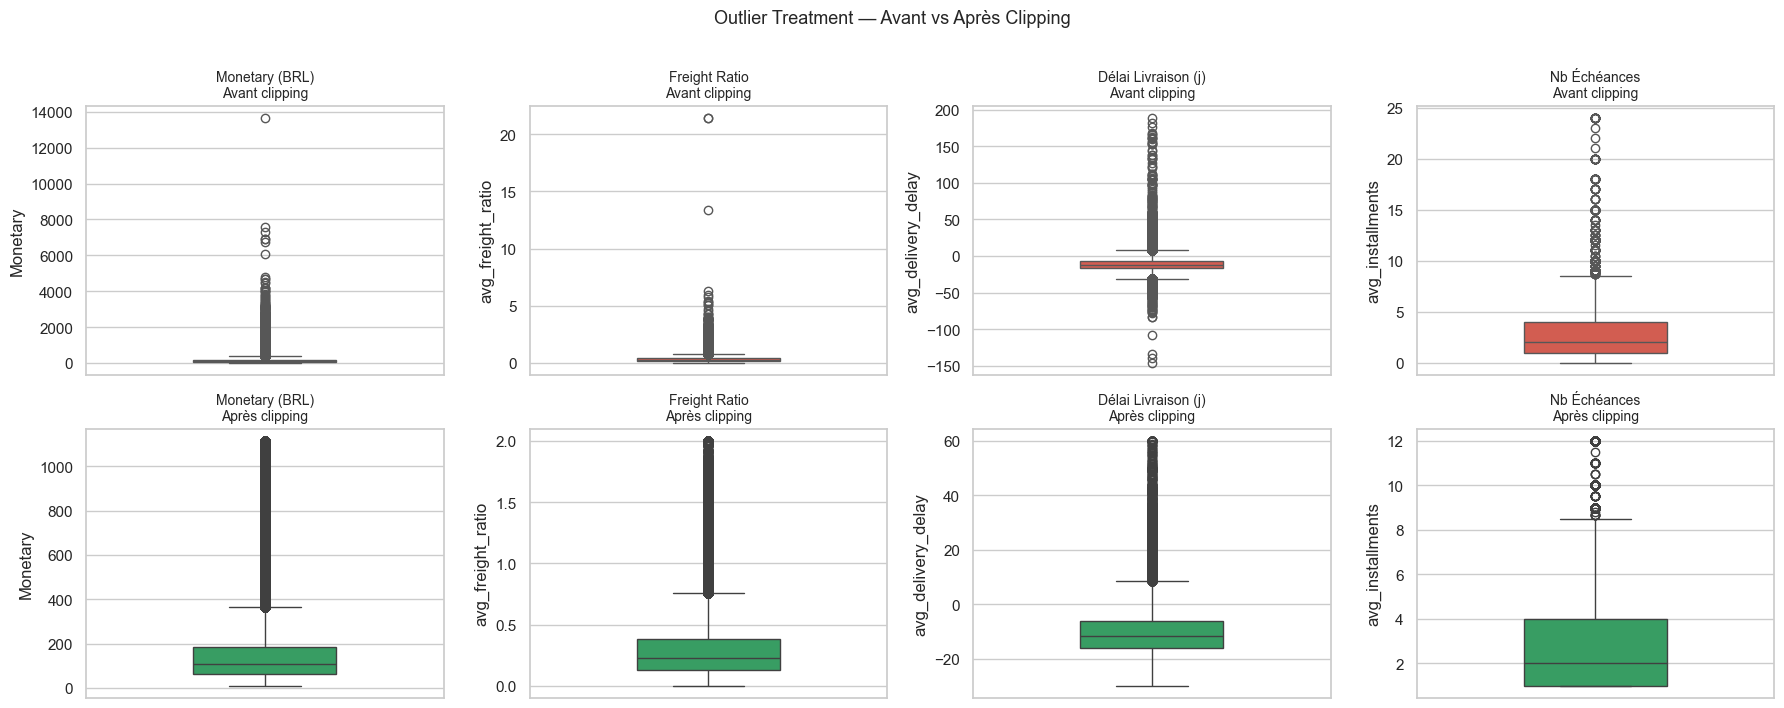


── Valeurs affectées par le clipping ──
   Monetary                  :   935 clients affectés (1.00%)
   avg_freight_ratio         :   318 clients affectés (0.34%)
   avg_delivery_delay        : 2,308 clients affectés (2.47%)
   avg_installments          :   163 clients affectés (0.17%)


In [6]:
# ── Capture des valeurs avant clipping (pour visualisation) ───────────────────
outlier_cols = ['Monetary', 'avg_freight_ratio', 'avg_delivery_delay', 'avg_installments']
before_clip  = {c: df_features[c].copy() for c in outlier_cols}

# ── Clipping ──────────────────────────────────────────────────────────────────
p99_monetary = df_features['Monetary'].quantile(0.99)
df_features['Monetary']           = df_features['Monetary'].clip(upper=p99_monetary)
df_features['avg_freight_ratio']  = df_features['avg_freight_ratio'].clip(lower=0, upper=2.0)
df_features['avg_delivery_delay'] = df_features['avg_delivery_delay'].clip(lower=-30, upper=60)
df_features['avg_installments']   = df_features['avg_installments'].clip(lower=1, upper=12)

print(f'Monetary P99 (borne supérieure) : R$ {p99_monetary:,.0f}')

# ── Visualisation avant / après ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
titles = ['Monetary (BRL)', 'Freight Ratio', 'Délai Livraison (j)', 'Nb Échéances']

for i, (col, title) in enumerate(zip(outlier_cols, titles)):
    # Avant
    sns.boxplot(y=before_clip[col].dropna(), ax=axes[0, i], color='#e74c3c', width=0.4)
    axes[0, i].set_title(f'{title}\nAvant clipping', fontsize=10)
    # Après
    sns.boxplot(y=df_features[col].dropna(), ax=axes[1, i], color='#27ae60', width=0.4)
    axes[1, i].set_title(f'{title}\nAprès clipping', fontsize=10)

plt.suptitle('Outlier Treatment — Avant vs Après Clipping', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Résumé du nombre de valeurs clipées
print('\n── Valeurs affectées par le clipping ──')
for col, before in before_clip.items():
    n_affected = (before != df_features[col]).sum()
    pct = n_affected / len(df_features) * 100
    print(f'   {col:<25} : {n_affected:>5,} clients affectés ({pct:.2f}%)')

## Section 5 — Imputation des Valeurs Manquantes

Après le clipping, certaines valeurs nulles subsistent pour des raisons structurelles :
- `avg_freight_ratio` : commandes avec `price = 0` → ratio indéfini → imputer médiane nationale
- `avg_delivery_delay` : si toutes les commandes d'un client manquent de date → imputer 0 (ni en avance ni en retard)
- `region_freight_score` : états non mappés → imputer 3 (Centro-Oeste = médiane nationale)
- `avg_review_score` : clients sans review → imputer médiane nationale
- `avg_installments` : clients qui n'ont pas de paiement CB → imputer 1 (pas d'échelonnement)

**L'assertion finale est un garde-fou de production :** si des nulls résiduels persistent, le notebook s'arrête avec une erreur explicite plutôt que de propager des NaN silencieux dans le clustering.

In [7]:
FINAL_FEATURES = [
    'Log_Recency', 'Log_Monetary', 'Frequency_flag',
    'avg_freight_ratio', 'avg_delivery_delay', 'avg_review_score',
    'payment_type_cc_flag', 'avg_installments', 'region_freight_score'
]

# Colonnes à imputer (avant log-transform)
PRE_TRANSFORM_COLS = [
    'avg_freight_ratio', 'avg_delivery_delay', 'avg_review_score',
    'payment_type_cc_flag', 'avg_installments', 'region_freight_score'
]

IMPUTATION_MAP = {
    'Recency':             df_features['Recency'].median(),   # quelques clients sans date de livraison
    'Monetary':            df_features['Monetary'].median(),  # quelques clients sans montant total
    'avg_freight_ratio':   df_features['avg_freight_ratio'].median(),
    'avg_delivery_delay':  0.0,
    'avg_review_score':    df_features['avg_review_score'].median(),
    'payment_type_cc_flag': 0,   # si pas de paiement CB dominant → flag = 0
    'avg_installments':    1.0,
    'region_freight_score': 3,   # Centro-Oeste = score médian
}

print('── Valeurs imputées ──')
for col, val in IMPUTATION_MAP.items():
    n_null = df_features[col].isna().sum()
    if n_null > 0:
        print(f'   {col:<25} : {n_null:>5,} nulls → imputé à {val}')

df_features.fillna(IMPUTATION_MAP, inplace=True)

assert df_features['Recency'].isna().sum() == 0,  'Recency contient des nulls !'
assert df_features['Monetary'].isna().sum() == 0, 'Monetary contient des nulls !'
assert df_features[PRE_TRANSFORM_COLS].isnull().sum().sum() == 0, \
    f'Nulls résiduels détectés dans : {df_features[PRE_TRANSFORM_COLS].isnull().sum()[df_features[PRE_TRANSFORM_COLS].isnull().sum() > 0].to_dict()}'

print('\n✅ Assertion OK — Aucun null résiduel dans les features finales.')

── Valeurs imputées ──
   Monetary                  :     1 nulls → imputé à 107.9
   avg_delivery_delay        :     8 nulls → imputé à 0.0
   avg_review_score          :   603 nulls → imputé à 5.0
   payment_type_cc_flag      :     1 nulls → imputé à 0
   avg_installments          :     1 nulls → imputé à 1.0

✅ Assertion OK — Aucun null résiduel dans les features finales.


## Section 6 — Log-Transformation & Constitution du Feature Set Final

La **log-transformation** (log1p = log(x+1)) résout deux problèmes simultanément :
1. **Skewness** : `Recency` et `Monetary` ont des distributions fortement asymétriques (skewness > 3 confirmé en EDA). K-Means est sensible au skewness — un client avec Monetary = 5 000 BRL dominerait tous les clusters si on utilisait les valeurs brutes.
2. **Outliers résiduels** : après clipping, des valeurs extrêmes persistent. Le log les compresse vers le centre de la distribution.

**`Frequency_flag`** reste binaire (0/1) — une log-transformation n'apporterait rien sur une variable binaire.

Les 9 features finales après cette étape forment le **feature set canonique** pour tous les algorithmes de clustering.

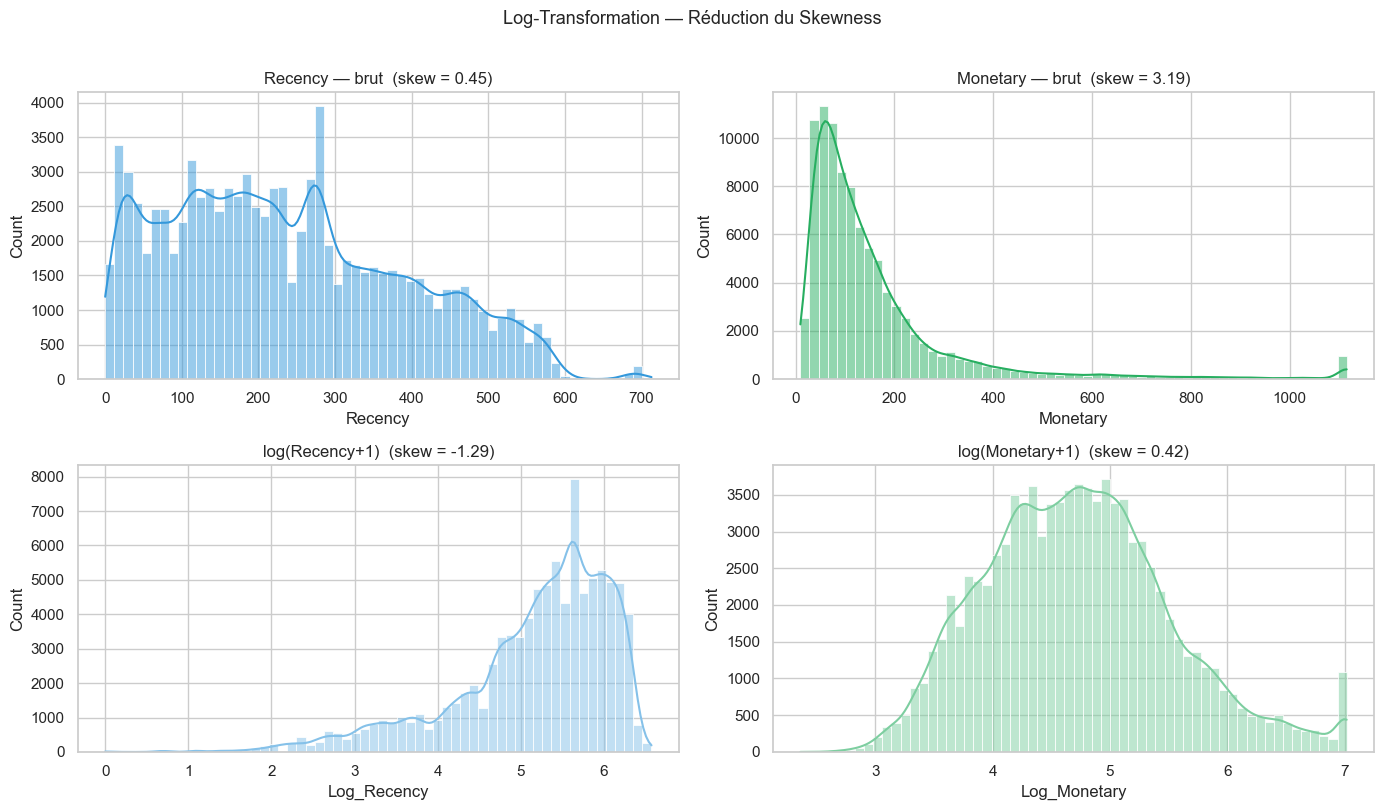


── Feature Set Final (9 features) ──


,Feature,Mean,Std,Skewness,Min,Max
0,Log_Recency,5.155,0.951,-1.289,0.000,6.571
1,Log_Monetary,4.728,0.798,0.422,2.360,7.018
2,Frequency_flag,0.030,0.171,5.510,0.000,1.000
3,avg_freight_ratio,0.306,0.277,2.550,0.000,2.000
4,avg_delivery_delay,-11.039,9.280,1.322,-30.000,60.000
5,avg_review_score,4.159,1.278,-1.488,1.000,5.000
6,payment_type_cc_flag,0.755,0.430,-1.185,0.000,1.000
7,avg_installments,2.891,2.637,1.473,1.000,12.000
8,region_freight_score,2.160,0.849,1.344,1.000,5.000


In [8]:
# ── Log-transformations ────────────────────────────────────────────────────────
df_features['Log_Recency']  = np.log1p(df_features['Recency'])
df_features['Log_Monetary'] = np.log1p(df_features['Monetary'])

# ── Visualisation avant / après log ───────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
pairs = [
    ('Recency',  'Log_Recency',  '#3498db', '#85c1e9'),
    ('Monetary', 'Log_Monetary', '#27ae60', '#7dcea0'),
]
for col, (raw, log, cr, cl) in enumerate(pairs):
    skew_raw = df_features[raw].skew()
    skew_log = df_features[log].skew()
    sns.histplot(df_features[raw], bins=60, kde=True, ax=axes[0, col], color=cr)
    axes[0, col].set_title(f'{raw} — brut  (skew = {skew_raw:.2f})')
    sns.histplot(df_features[log], bins=60, kde=True, ax=axes[1, col], color=cl)
    axes[1, col].set_title(f'log({raw}+1)  (skew = {skew_log:.2f})')

plt.suptitle('Log-Transformation — Réduction du Skewness', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── Résumé du feature set final ───────────────────────────────────────────────
print('\n── Feature Set Final (9 features) ──')
summary = pd.DataFrame({
    'Feature':   FINAL_FEATURES,
    'Mean':      df_features[FINAL_FEATURES].mean().round(3).values,
    'Std':       df_features[FINAL_FEATURES].std().round(3).values,
    'Skewness':  df_features[FINAL_FEATURES].skew().round(3).values,
    'Min':       df_features[FINAL_FEATURES].min().round(3).values,
    'Max':       df_features[FINAL_FEATURES].max().round(3).values,
})
display(summary.style.format('{:.3f}', subset=['Mean','Std','Skewness','Min','Max'])
        .background_gradient(cmap='RdYlGn_r', subset=['Skewness'], vmin=-2, vmax=2))

## Section 7 — Normalisation StandardScaler

Le `StandardScaler` centre chaque feature à **moyenne 0** et l'échelle à **écart-type 1**. C'est la transformation requise avant :
- **K-Means** : distance euclidienne — une feature non normalisée en milliers domine la fonction objectif
- **CAH** (hierarchical clustering) : idem
- **DBSCAN** : le paramètre `eps` est sensible à l'échelle — une feature non normalisée change radicalement le voisinage

Le scaler est **sauvegardé en production** via `joblib`. Lors du scoring d'un nouveau client, on applique le même scaler (fit sur les données d'entraînement) — jamais on ne re-fit sur les données de production.

Scaler sauvegardé : /Users/mac/Downloads/School Projects/olist-customer-segmentation/models/standard_scaler.pkl

✅ Assertions OK — mean ≈ 0 et std ≈ 1 pour toutes les features.


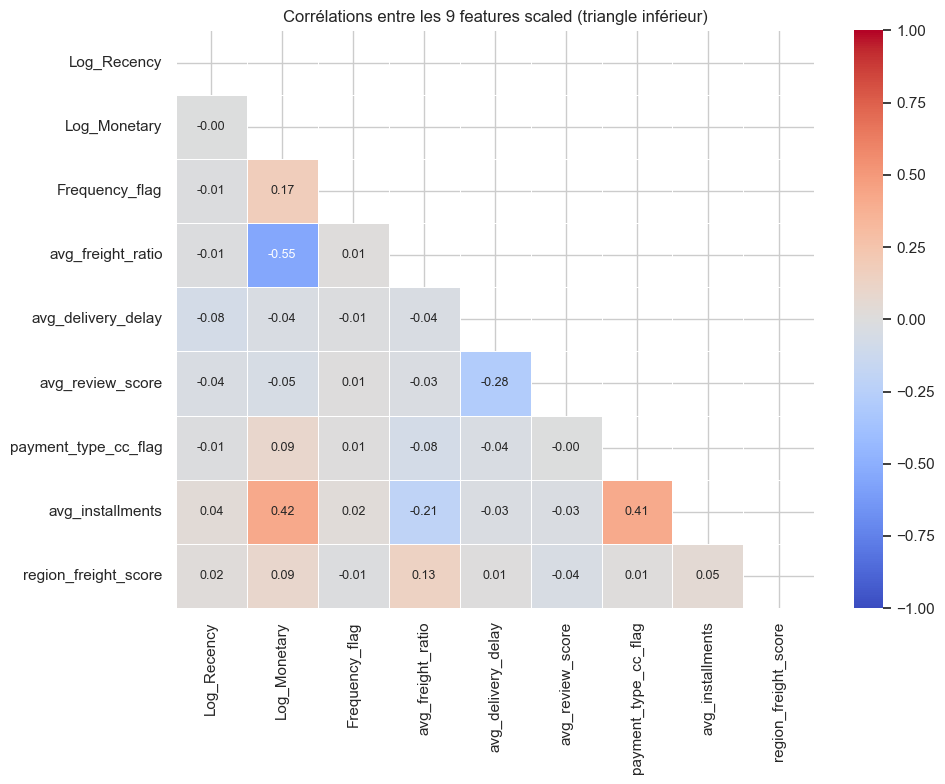


✅ Aucune paire avec |ρ| > 0.6 — features bien décorrélées.


In [9]:
# ── Extraction du feature set brut (non scaled) ───────────────────────────────
X_raw = df_features[FINAL_FEATURES].copy()

# ── StandardScaler ────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled_arr = scaler.fit_transform(X_raw)
X_scaled = pd.DataFrame(
    X_scaled_arr,
    columns=FINAL_FEATURES,
    index=df_features['customer_unique_id'].values
)
X_scaled.index.name = 'customer_unique_id'

# ── Sauvegarde du scaler ───────────────────────────────────────────────────────
scaler_path = MODELS_DIR / 'standard_scaler.pkl'
joblib.dump(scaler, scaler_path)
print(f'Scaler sauvegardé : {scaler_path}')

# ── Vérifications post-scaling ────────────────────────────────────────────────
means = X_scaled.mean().round(5)
stds  = X_scaled.std().round(5)

assert (means.abs() < 1e-4).all(), f'Mean non nul après scaling : {means[means.abs() >= 1e-4]}'
assert ((stds - 1).abs() < 1e-4).all(), f'Std ≠ 1 après scaling : {stds[(stds-1).abs() >= 1e-4]}'

print('\n✅ Assertions OK — mean ≈ 0 et std ≈ 1 pour toutes les features.')

# ── Heatmap de corrélation post-scaling ───────────────────────────────────────
corr = X_scaled.corr()
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, mask=mask, ax=ax,
            linewidths=0.4, linecolor='white', annot_kws={'size': 9})
ax.set_title('Corrélations entre les 9 features scaled (triangle inférieur)', fontsize=12)
plt.tight_layout()
plt.show()

# Identification des paires fortement corrélées (|ρ| > 0.6)
high_corr = (
    corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
    .rename(columns={'level_0': 'Feature A', 'level_1': 'Feature B', 0: 'Corrélation'})
)
high_corr = high_corr[high_corr['Corrélation'].abs() > 0.6].sort_values('Corrélation', ascending=False)
if len(high_corr) > 0:
    print('\n⚠️  Paires fortement corrélées (|ρ| > 0.6) — à surveiller pour la réduction de dimension :')
    display(high_corr)
else:
    print('\n✅ Aucune paire avec |ρ| > 0.6 — features bien décorrélées.')

## Section 8 — Export, Diagnostics Finaux & Sanity Check PCA

Deux artefacts sont exportés :
- **`customer_features_raw.parquet`** : feature store non normalisé — utile pour l'interprétation des clusters ("le segment X a un Monetary médian de R$250"), pour le dashboard, et pour les tests unitaires
- **`customer_features_scaled.parquet`** : feature store normalisé — input direct des algorithmes de clustering dans le notebook 03

La **projection PCA 2D** n'est pas une feature engineering step — c'est un **sanity check visuel** : si les données sont clusterables, on doit voir une structure (groupes, gradients) même en 2 dimensions. Un nuage uniforme sans structure suggère que les features ne discriminent pas.

✅ Exportés :
   /Users/mac/Downloads/School Projects/olist-customer-segmentation/data/processed/customer_features_raw.parquet
   /Users/mac/Downloads/School Projects/olist-customer-segmentation/data/processed/customer_features_scaled.parquet

══════════════════════════════════════════════════════
  FEATURE STORE — RÉCAPITULATIF FINAL
══════════════════════════════════════════════════════
  Clients dans le feature store   :   93,358
  Features retenues               :        9
  % nulls résiduels               :    0.00%
  Skewness max post-transformation :   5.510
  Frequency_flag = 1 (F≥2)        :     3.0%
  Scaler sauvegardé               : standard_scaler.pkl
══════════════════════════════════════════════════════



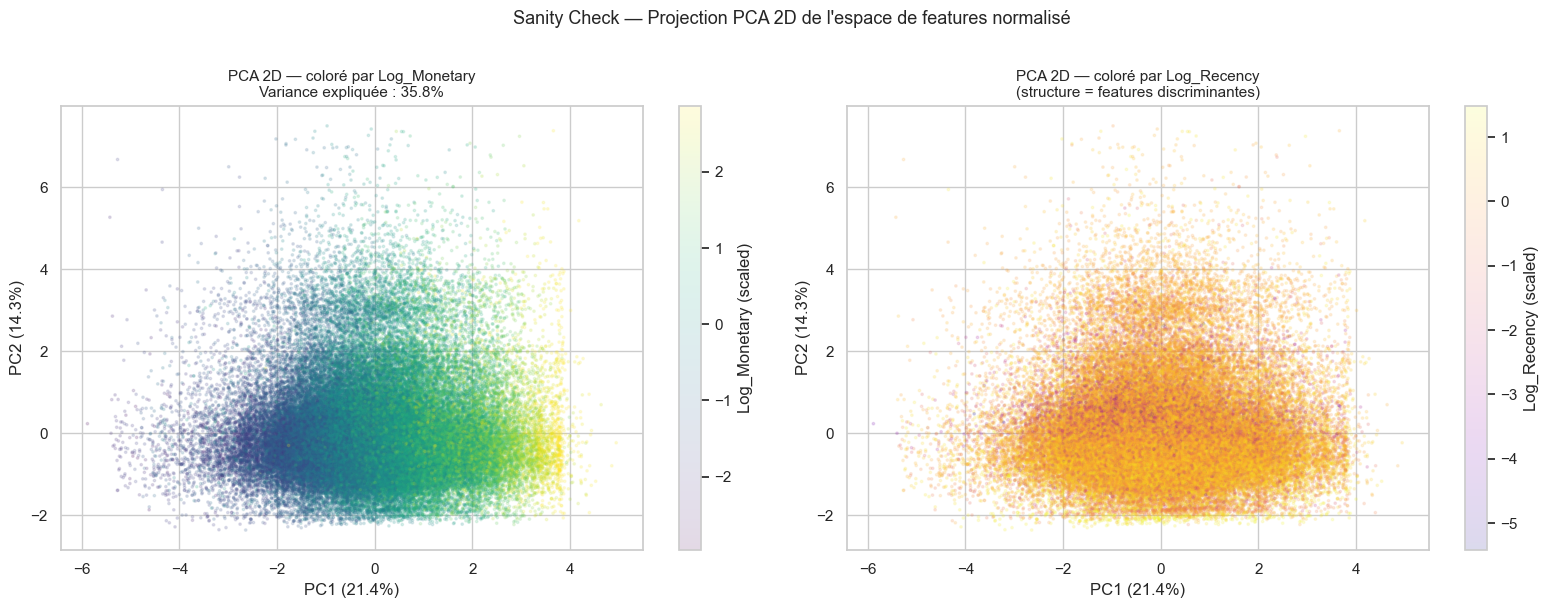


── Loadings PCA (contribution de chaque feature aux composantes) ──


,PC1,PC2
Log_Recency,0.024,-0.083
Log_Monetary,0.591,0.047
Frequency_flag,0.120,-0.026
avg_freight_ratio,-0.491,-0.024
avg_delivery_delay,-0.032,0.702
avg_review_score,-0.028,-0.691
payment_type_cc_flag,0.333,-0.076
avg_installments,0.531,-0.016
region_freight_score,0.023,0.110



Variance expliquée PC1 : 21.4%
Variance expliquée PC2 : 14.3%
Total PC1+PC2          : 35.8%

→ Le notebook 03 (clustering) chargera customer_features_scaled.parquet directement.


In [10]:
# ── Export Parquet ─────────────────────────────────────────────────────────────
raw_path    = PROCESSED_DIR / 'customer_features_raw.parquet'
scaled_path = PROCESSED_DIR / 'customer_features_scaled.parquet'

df_features.to_parquet(raw_path, index=False)
X_scaled.reset_index().to_parquet(scaled_path, index=False)

print(f'✅ Exportés :')
print(f'   {raw_path}')
print(f'   {scaled_path}')

# ── Dashboard récapitulatif ────────────────────────────────────────────────────
print(f"""
══════════════════════════════════════════════════════
  FEATURE STORE — RÉCAPITULATIF FINAL
══════════════════════════════════════════════════════
  Clients dans le feature store   : {len(df_features):>8,}
  Features retenues               : {len(FINAL_FEATURES):>8}
  % nulls résiduels               : {df_features[FINAL_FEATURES].isnull().mean().mean()*100:>7.2f}%
  Skewness max post-transformation : {df_features[FINAL_FEATURES].skew().abs().max():>7.3f}
  Frequency_flag = 1 (F≥2)        : {df_features['Frequency_flag'].mean()*100:>7.1f}%
  Scaler sauvegardé               : {scaler_path.name}
══════════════════════════════════════════════════════
""")

# ── PCA 2D — Sanity Check Visuel ─────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_arr)
var_explained = pca.explained_variance_ratio_.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter coloré par Log_Monetary
sc1 = axes[0].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=X_scaled['Log_Monetary'].values, cmap='viridis',
    alpha=0.15, s=3
)
plt.colorbar(sc1, ax=axes[0], label='Log_Monetary (scaled)')
axes[0].set_title(f'PCA 2D — coloré par Log_Monetary\nVariance expliquée : {var_explained:.1f}%', fontsize=11)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')

# Scatter coloré par Log_Recency
sc2 = axes[1].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=X_scaled['Log_Recency'].values, cmap='plasma',
    alpha=0.15, s=3
)
plt.colorbar(sc2, ax=axes[1], label='Log_Recency (scaled)')
axes[1].set_title(f'PCA 2D — coloré par Log_Recency\n(structure = features discriminantes)', fontsize=11)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')

plt.suptitle('Sanity Check — Projection PCA 2D de l\'espace de features normalisé', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Contribution des features aux axes PCA
loadings = pd.DataFrame(
    pca.components_.T,
    index=FINAL_FEATURES,
    columns=['PC1', 'PC2']
).round(3)

print(f'\n── Loadings PCA (contribution de chaque feature aux composantes) ──')
display(loadings.style.background_gradient(cmap='RdBu', vmin=-1, vmax=1)
        .format('{:.3f}'))

print(f'\nVariance expliquée PC1 : {pca.explained_variance_ratio_[0]*100:.1f}%')
print(f'Variance expliquée PC2 : {pca.explained_variance_ratio_[1]*100:.1f}%')
print(f'Total PC1+PC2          : {var_explained:.1f}%')
print(f'\n→ Le notebook 03 (clustering) chargera {scaled_path.name} directement.')